In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn.functional as F
from scipy.signal import *
import os

In [5]:
collectedCSV  = glob("vctk/gen/csv/wav48_silence_trimmed/*/*.csv")
collectedFLAC = [csv.replace("vctk/gen/csv", "vctk/stock").replace("csv", "flac") for csv in collectedCSV]
Fs = 16000

#print(torchaudio.utils.sox_utils.list_read_formats())

print(torchaudio.list_audio_backends())

for e  in collectedFLAC:
    if not os.path.isfile(e):
        print(e)
    #print( torchaudio.info(e))


['sox', 'soundfile']


In [6]:
Ls = []
for flac_fn in tqdm(collectedFLAC):
    print(flac_fn)
    flacData, sr = torchaudio.load(flac_fn, backend="soundfile")
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    L = flacData.shape[-1]
    Ls.append(L)
maxLen = max(Ls)

  0%|▏                                                                                                                   | 12/8942 [00:00<01:16, 116.93it/s]

vctk/stock/wav48_silence_trimmed/p240/p240_352_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_273_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_209_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_105_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_362_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_331_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_087_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_184_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_150_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_231_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_297_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_228_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_048_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_061_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_291_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_326_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_111_mic2.flac
vctk/stock/wav48_silence_trimme

  1%|▌                                                                                                                   | 48/8942 [00:00<00:55, 161.45it/s]

vctk/stock/wav48_silence_trimmed/p240/p240_343_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_305_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_248_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_007_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_234_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_271_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_256_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_280_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_093_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_100_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_079_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_080_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_106_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_219_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_190_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_118_mic2.flac
vctk/stock/wav48_silence_trimmed/p240/p240_201_mic2.flac
vctk/stock/wav48_silence_trimme

  1%|█▏                                                                                                                  | 95/8942 [00:00<00:43, 204.94it/s]

...

  8%|████████▊                                                                                                          | 686/8942 [00:03<00:45, 180.33it/s]

vctk/stock/wav48_silence_trimmed/p230/p230_369_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_007_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_377_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_019_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_231_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_204_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_172_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_237_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_044_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_025_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_405_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_372_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_414_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_092_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_054_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_288_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_234_mic2.flac
vctk/stock/wav48_silence_trimme

  8%|█████████▏                                                                                                         | 715/8942 [00:03<00:41, 199.20it/s]

vctk/stock/wav48_silence_trimmed/p230/p230_257_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_316_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_128_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_033_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_065_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_151_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_027_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_023_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_407_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_283_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_079_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_227_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_311_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_389_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_169_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_409_mic2.flac
vctk/stock/wav48_silence_trimmed/p230/p230_314_mic2.flac
vctk/stock/wav48_silence_trimme

KeyboardInterrupt: 

In [4]:
def getSpectrum(signal, maxLen):
    signal = F.pad(signal, (0, maxLen - signal.shape[-1]))
    signal = signal / torch.sqrt(torch.sum(signal ** 2))
    signalSpec = torch.fft.rfft(signal).abs()
    return signalSpec

def loadFlac(flac_fn):
    flacData, sr = torchaudio.load(flac_fn)
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    return flacData[0, :]

In [25]:
N = 200 # Sample 200 poitns for approximating the spectrum
gtSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # ground truth spectrum
mouseXSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum
mouseYSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum

pbar = tqdm(total=N)
for csv_fn, flac_fn in zip(collectedCSV[:N], collectedFLAC[:N]):
    # Load mouse data
    _, X, Y = processFromFile(csv_fn, maxTimesteps= None, skipPCA = True)
    
    # Load ground truth
    groundTruth = loadFlac(flac_fn)
    
    # Pad, FFT, normalize, and accumulate
    gtSpec += getSpectrum(groundTruth, maxLen) / N # divide here instead of outside the loop to avoid numerical issues (common when N is large)
    mouseXSpec += getSpectrum(X, maxLen) / N
    mouseYSpec += getSpectrum(Y, maxLen) / N
    
    pbar.update(1)
pbar.close()

NameError: name 'maxLen' is not defined

In [159]:
maxLen

226209

In [141]:
_, noiseX, noiseY = processFromFile("noise.csv", skipPCA = True)
k = torch.ceil(torch.tensor(noiseX.shape[0] / maxLen, dtype=torch.long)).item()
xz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
xz = noiseX[:xz.shape[0]]
xz = xz.reshape((k, maxLen))
yz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
yz = noiseY[:yz.shape[0]]
yz = yz.reshape((k, maxLen))
xzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
yzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
for x, y in zip(xz, yz):
    xzSpec += getSpectrum(x, maxLen) / k
    yzSpec += getSpectrum(y, maxLen) / k

/home/mo/.local/lib/python3.10/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)


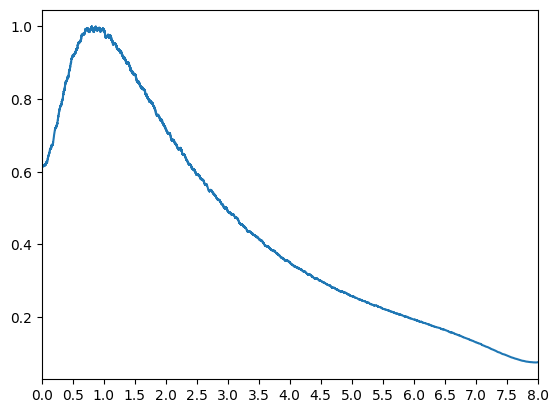

In [143]:
filtered = savgol_filter((xzSpec + yzSpec), 1001, 3)
noiseSpecSmooth = torch.tensor(filtered)
noiseSpecSmooth = noiseSpecSmooth / noiseSpecSmooth.abs().max()
plt.plot(noiseSpecSmooth.abs(), label="xz")
xlim = maxLen //2 + 1
xlimHz = xlim * Fs / maxLen
xticksHz = torch.arange(0, xlimHz + 1, 500)
xticks = xticksHz * maxLen / Fs
xticks_labels = [f"{x/1000:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.show()

/home/mo/mambaforge/envs/micemouse/lib/python3.10/site-packages/torch/_tensor.py:972: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)


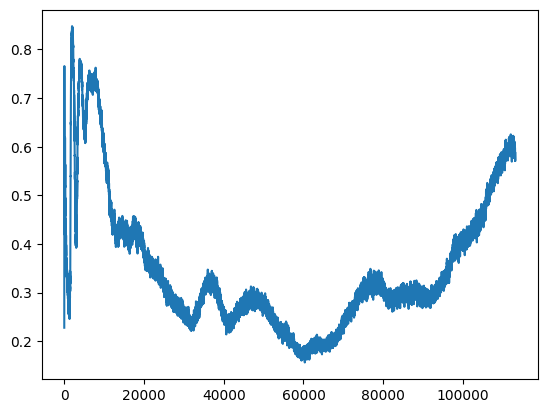

In [144]:
ratio = mouseYSpec/noiseSpecSmooth
ratio[:10_000] = ratio[10_000]
# running average
ratio = savgol_filter(ratio, 1001, 3)
newNoiseSpec = noiseSpecSmooth * (ratio.mean())
H = gtSpec / (gtSpec + newNoiseSpec)
plt.plot(H)

/tmp/ipykernel_4570/2110262829.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torchaudio.save("test.mp3", torch.tensor(test.unsqueeze(0), dtype=torch.float32), Fs)


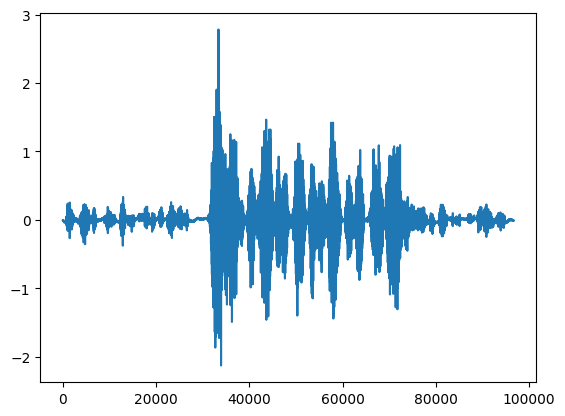

In [158]:
_, xtest, ytest = processFromFile(collectedCSV[0], skipPCA= True)
origLen = xtest.shape[-1]
xtest = F.pad(xtest, (0, maxLen - xtest.shape[-1]))
ytest = F.pad(ytest, (0, maxLen - ytest.shape[-1]))
xtestSpec = torch.fft.rfft(xtest)
ytestSpec = torch.fft.rfft(ytest)
testSpec = (xtestSpec + ytestSpec) * H
test = torch.fft.irfft(testSpec)
test = test[:origLen]
test = torch.tensor(wiener(test, 1001, 0.2))
plt.plot(test)
torchaudio.save("test.mp3", torch.tensor(test.unsqueeze(0), dtype=torch.float32), Fs)
# plt.plot(ytest)

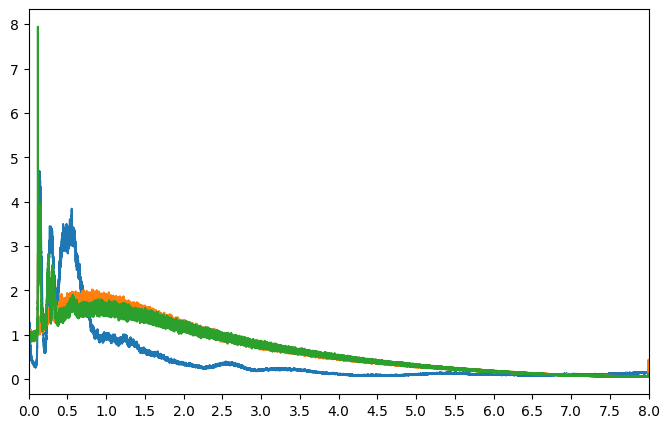

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(gtSpec)
plt.plot(mouseXSpec)
plt.plot(mouseYSpec)
xlim = maxLen //2 + 1
xlimHz = xlim * Fs / maxLen
xticksHz = torch.arange(0, xlimHz + 1, 500)
xticks = xticksHz * maxLen / Fs
xticks_labels = [f"{x/1000:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.show()

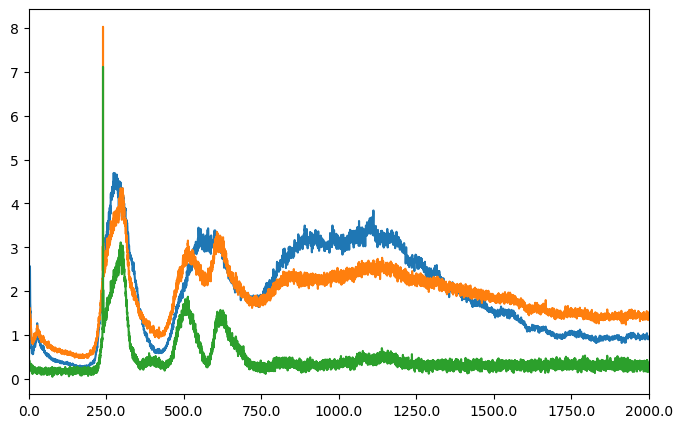

In [122]:

lowpass_cutoff_freq = 2000
lowpasslocation = int(lowpass_cutoff_freq * (maxLen//2+1) / Fs)

Ycv = (mouseXSpec[:lowpasslocation] + mouseYSpec[:lowpasslocation]) * H[:lowpasslocation]
# apply wiener on Ycv
# Ycv = wiener(Ycv, mysize=101, noise=noiseSpecSmooth[:lowpasslocation].std().item())
# Ycv = torch.tensor(Ycv)
# Zoom on the lowpass region
plt.figure(figsize=(8, 5))
plt.plot(gtSpec[:lowpasslocation])
plt.plot(Ycv)
plt.plot(mouseYSpec[:lowpasslocation] - newNoiseSpec[:lowpasslocation])
xlim = lowpasslocation
xlimHz = xlim * Fs / (maxLen/2)
xticksHz = torch.arange(0, xlimHz + 1, 250)
xticks = xticksHz * (maxLen / 2) / Fs
xticks_labels = [f"{x:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.show()

In [181]:
def find_offset_for_maximal_correlation(signal_a, signal_b):
    """
    Returns the offset of signal_a in signal_b that maximizes the correlation between the two.
    """
    # make sure signal_a is shorter than signal_b, needed for the convolution filter
    if signal_a.shape[0] >= signal_b.shape[0]:
        signal_a, signal_b = signal_b, signal_a
    signal_a = signal_a.view(1, 1, -1)
    norm_a = torch.ones_like(signal_a)
    signal_b = signal_b.view(1, 1, -1)
    norm_b = torch.ones_like(signal_b)
    pad = signal_a.shape[-1] - 1
    correlation = F.conv1d(signal_b, signal_a, padding=pad).view(-1)
    norm_coeff = F.conv1d(norm_b, norm_a, padding=pad).view(-1)
    correlation = correlation / norm_coeff
    best_offset = torch.argmax(correlation)
    return best_offset.item()